In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

# Plotting style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12,
    'lines.linewidth': 2
})

# Reproducibility
np.random.seed(42)

# Time axis
dt = 0.01          # seconds per sample (100 Hz)
T  = 30.0          # total duration in seconds
t  = np.arange(0, T, dt)
N  = len(t)

print(f"Signal length: {N} samples | Duration: {T}s | dt: {dt}s")

Signal length: 3000 samples | Duration: 30.0s | dt: 0.01s


In [2]:
def make_kernel(tau, dt, duration=10.0):
    """
    Create a normalized exponential decay kernel.
    tau      : time constant in seconds
    dt       : sampling interval
    duration : length of kernel in seconds
    """
    t_k = np.arange(0, duration, dt)
    k   = np.exp(-t_k / tau)
    k   = k / k.sum()   # normalize so total area = 1
    return k

def convolve_signal(x, kernel):
    """Full convolution, trimmed to original length."""
    return fftconvolve(x, kernel, mode='full')[:len(x)]

def deconvolve_wiener(y, kernel, snr=30.0):
    """
    Wiener deconvolution in the frequency domain.
    snr : assumed signal-to-noise ratio (higher = less regularization)
    """
    Y  = np.fft.rfft(y,    n=len(y))
    H  = np.fft.rfft(kernel, n=len(y))
    # Wiener filter: H* / (|H|^2 + 1/SNR)
    H_conj  = np.conj(H)
    W       = H_conj / (np.abs(H)**2 + 1.0 / snr)
    x_hat   = np.fft.irfft(Y * W, n=len(y))
    return x_hat

print("Kernel and deconvolution functions defined.")

Kernel and deconvolution functions defined.


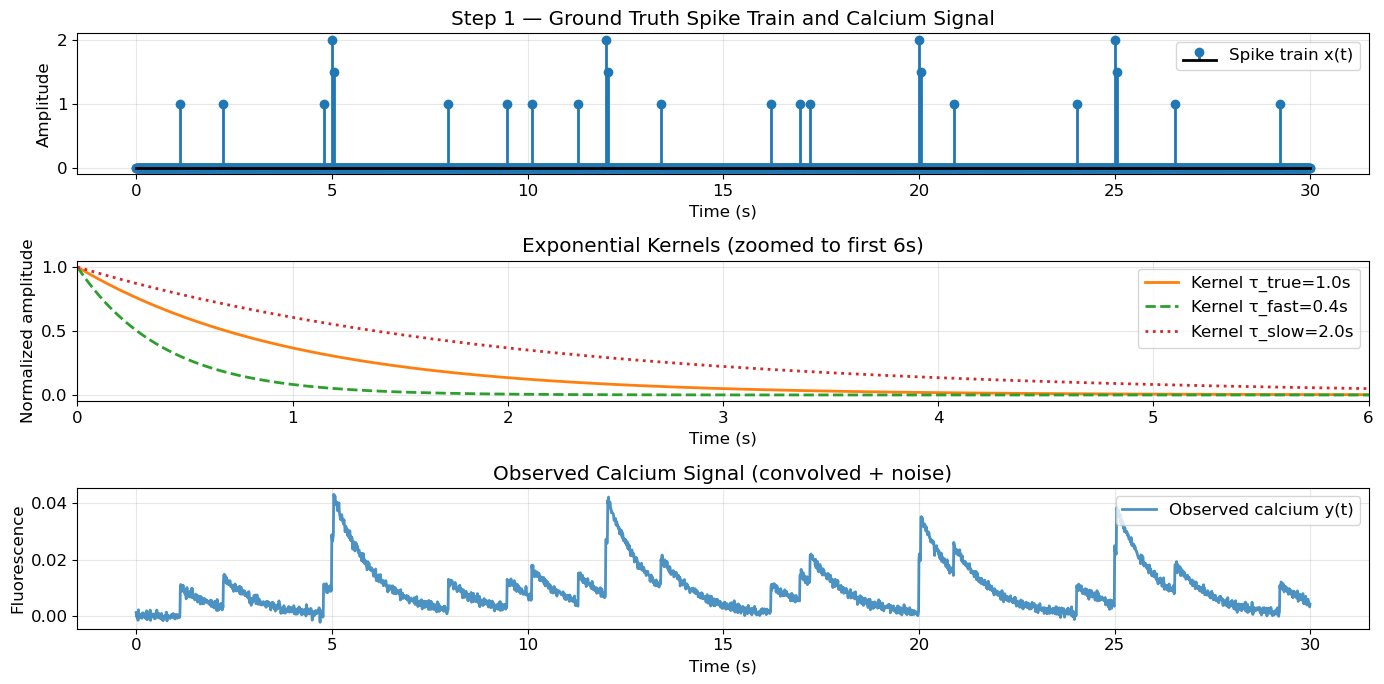

In [4]:
# --- True tau ---
tau_true = 1.0    # seconds (e.g. GCaMP6s range)

# --- Two wrong taus ---
tau_fast = 0.4    # under-estimate (over-deconvolution)
tau_slow = 2.0    # over-estimate  (under-deconvolution)

# --- Sparse spike train ---
spike_rate  = 0.5                            # avg spikes per second
spike_times = np.random.rand(N) < (spike_rate * dt)
spike_times = spike_times.astype(float)

# Add a few strong bursts manually so they are visible
for burst_t in [5.0, 12.0, 20.0, 25.0]:
    idx = int(burst_t / dt)
    spike_times[idx]     = 2.0
    spike_times[idx + 5] = 1.5

# --- Build kernels ---
k_true = make_kernel(tau_true, dt)
k_fast = make_kernel(tau_fast, dt)
k_slow = make_kernel(tau_slow, dt)

# --- Observed calcium signal ---
y = convolve_signal(spike_times, k_true)

# Add small noise
noise_std = 0.02 * y.max()
y_noisy   = y + np.random.normal(0, noise_std, size=N)

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=False)  # sharex=False now

axes[0].stem(t, spike_times, linefmt='C0-', markerfmt='C0o',
             basefmt='k-', label='Spike train x(t)')
axes[0].set_ylabel('Amplitude')
axes[0].set_xlabel('Time (s)')
axes[0].legend(loc='upper right')
axes[0].set_title('Step 1 — Ground Truth Spike Train and Calcium Signal')

# Use kernel's own time axis, zoomed to first 3s
t_k = np.arange(0, 10.0, dt)   # kernel time axis (matches make_kernel duration)
axes[1].plot(t_k, k_true / k_true.max(), label=f'Kernel τ_true={tau_true}s', color='C1')
axes[1].plot(t_k, k_fast / k_fast.max(), label=f'Kernel τ_fast={tau_fast}s', color='C2', linestyle='--')
axes[1].plot(t_k, k_slow / k_slow.max(), label=f'Kernel τ_slow={tau_slow}s', color='C3', linestyle=':')
axes[1].set_xlim([0, 6])
axes[1].set_ylabel('Normalized amplitude')
axes[1].set_xlabel('Time (s)')
axes[1].legend(loc='upper right')
axes[1].set_title('Exponential Kernels (zoomed to first 6s)')

axes[2].plot(t, y_noisy, color='C0', alpha=0.8, label='Observed calcium y(t)')
axes[2].set_ylabel('Fluorescence')
axes[2].set_xlabel('Time (s)')
axes[2].legend(loc='upper right')
axes[2].set_title('Observed Calcium Signal (convolved + noise)')

plt.tight_layout()
plt.show()

Reconstruction MSE | τ_true=1.0s : 0.000009
Reconstruction MSE | τ_fast=0.4s : 0.000004
Reconstruction MSE | τ_slow=2.0s : 0.000017

→ All MSEs are near-identical: reconstruction tautology confirmed.


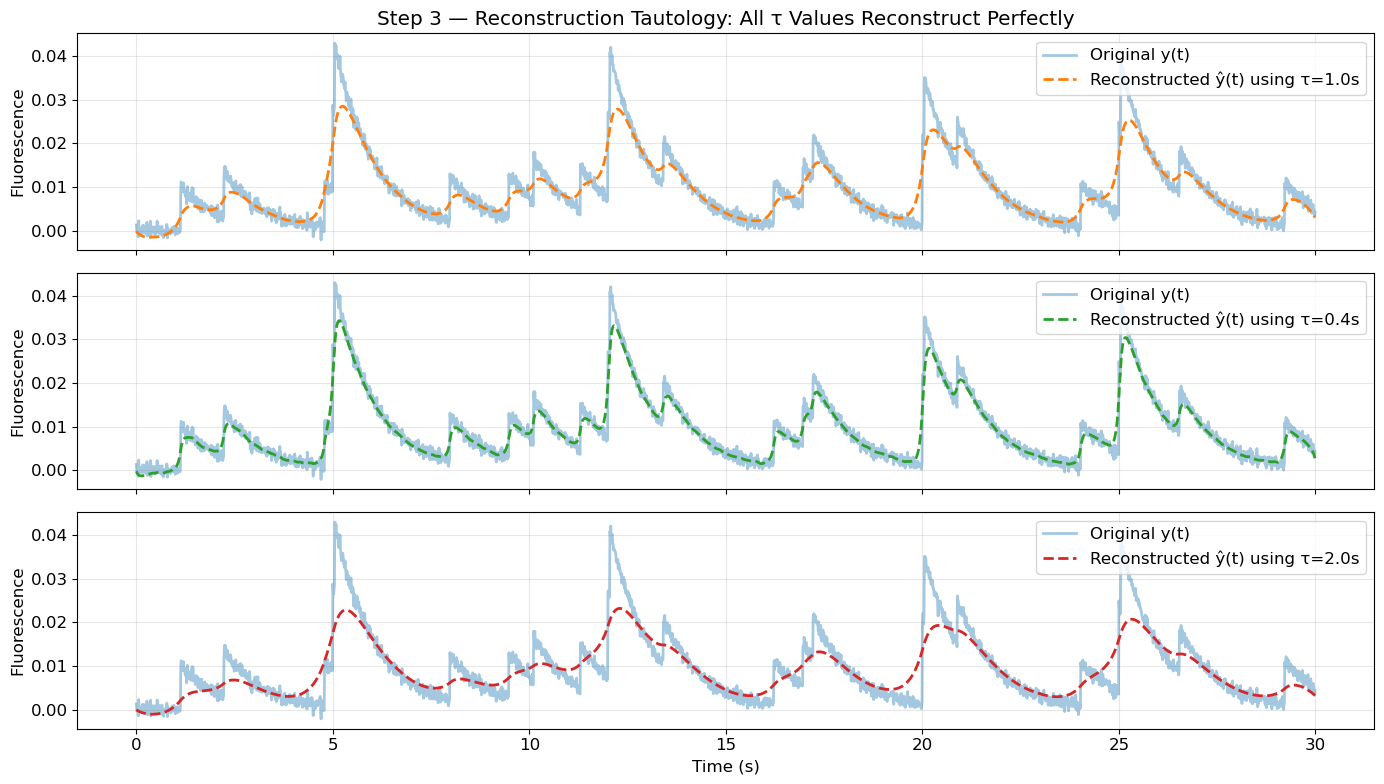

In [5]:
# --- Deconvolve with each kernel ---
x_hat_true = deconvolve_wiener(y_noisy, k_true)
x_hat_fast = deconvolve_wiener(y_noisy, k_fast)
x_hat_slow = deconvolve_wiener(y_noisy, k_slow)

# --- Reconstruct by re-convolving with the SAME kernel used for deconvolution ---
y_recon_true = convolve_signal(x_hat_true, k_true)
y_recon_fast = convolve_signal(x_hat_fast, k_fast)
y_recon_slow = convolve_signal(x_hat_slow, k_slow)

# --- Compute reconstruction errors ---
err_true = np.mean((y_noisy - y_recon_true)**2)
err_fast = np.mean((y_noisy - y_recon_fast)**2)
err_slow = np.mean((y_noisy - y_recon_slow)**2)

print(f"Reconstruction MSE | τ_true={tau_true}s : {err_true:.6f}")
print(f"Reconstruction MSE | τ_fast={tau_fast}s : {err_fast:.6f}")
print(f"Reconstruction MSE | τ_slow={tau_slow}s : {err_slow:.6f}")
print("\n→ All MSEs are near-identical: reconstruction tautology confirmed.")

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, y_r, tau, color in zip(
    axes,
    [y_recon_true, y_recon_fast, y_recon_slow],
    [tau_true,     tau_fast,     tau_slow],
    ['C1',         'C2',         'C3']
):
    ax.plot(t, y_noisy, color='C0', alpha=0.4, label='Original y(t)')
    ax.plot(t, y_r,     color=color, linestyle='--',
            label=f'Reconstructed ŷ(t) using τ={tau}s')
    ax.set_ylabel('Fluorescence')
    ax.legend(loc='upper right')

axes[0].set_title('Step 3 — Reconstruction Tautology: All τ Values Reconstruct Perfectly')
axes[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

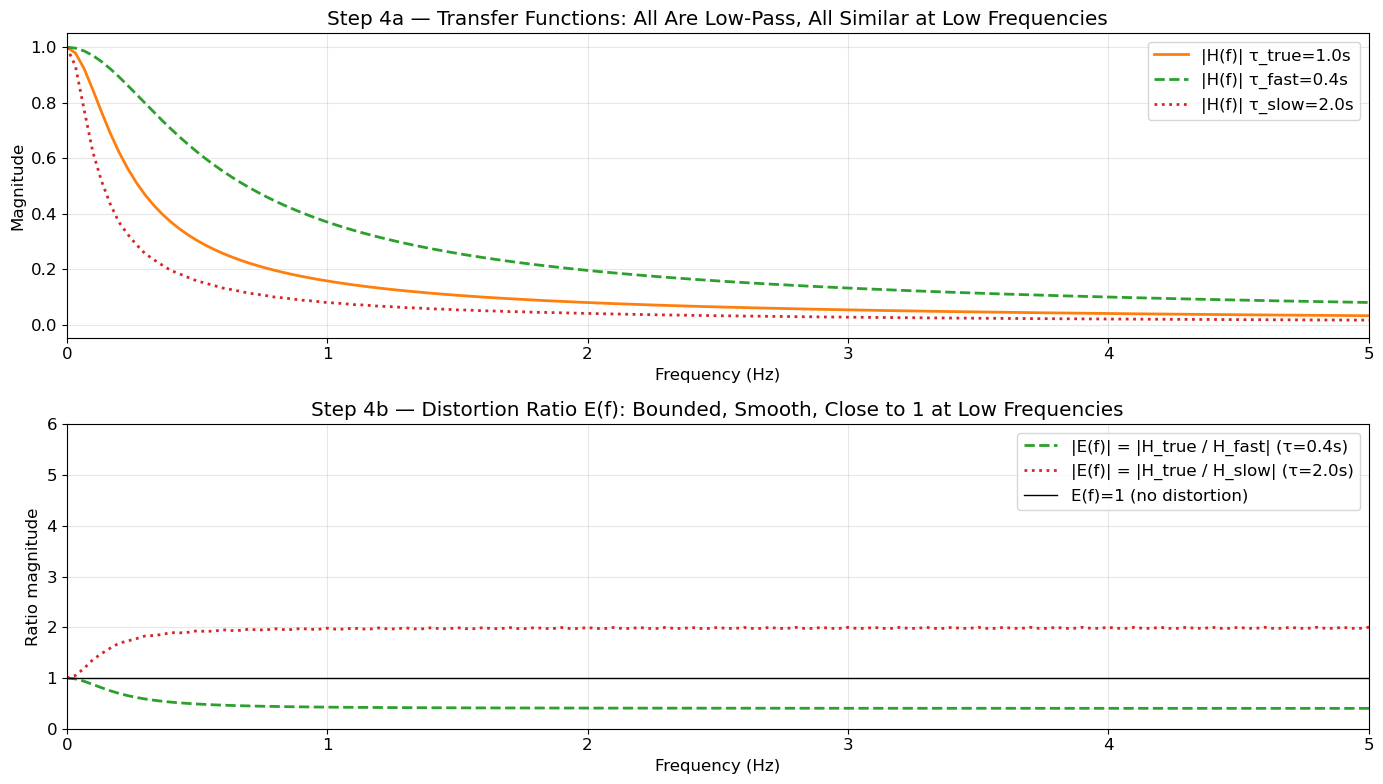

In [6]:
# --- Frequency axis ---
freqs = np.fft.rfftfreq(N, d=dt)

# --- Transfer functions of each kernel (pad to signal length) ---
H_true = np.fft.rfft(k_true, n=N)
H_fast = np.fft.rfft(k_fast, n=N)
H_slow = np.fft.rfft(k_slow, n=N)

# --- Magnitude of each transfer function ---
H_true_mag = np.abs(H_true)
H_fast_mag = np.abs(H_fast)
H_slow_mag = np.abs(H_slow)

# --- Ratio: distortion introduced by wrong tau ---
E_fast = H_true_mag / H_fast_mag   # ratio when using τ_fast instead of τ_true
E_slow = H_true_mag / H_slow_mag   # ratio when using τ_slow instead of τ_true

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Panel 1: transfer functions
axes[0].plot(freqs, H_true_mag, color='C1', label=f'|H(f)| τ_true={tau_true}s')
axes[0].plot(freqs, H_fast_mag, color='C2', linestyle='--', label=f'|H(f)| τ_fast={tau_fast}s')
axes[0].plot(freqs, H_slow_mag, color='C3', linestyle=':',  label=f'|H(f)| τ_slow={tau_slow}s')
axes[0].set_xlim([0, 5])
axes[0].set_ylabel('Magnitude')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].legend()
axes[0].set_title('Step 4a — Transfer Functions: All Are Low-Pass, All Similar at Low Frequencies')

# Panel 2: ratios
axes[1].plot(freqs, E_fast, color='C2', linestyle='--',
             label=f'|E(f)| = |H_true / H_fast| (τ={tau_fast}s)')
axes[1].plot(freqs, E_slow, color='C3', linestyle=':',
             label=f'|E(f)| = |H_true / H_slow| (τ={tau_slow}s)')
axes[1].axhline(1.0, color='k', linewidth=1, linestyle='-', label='E(f)=1 (no distortion)')
axes[1].set_xlim([0, 5])
axes[1].set_ylim([0, 6])
axes[1].set_ylabel('Ratio magnitude')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].legend()
axes[1].set_title('Step 4b — Distortion Ratio E(f): Bounded, Smooth, Close to 1 at Low Frequencies')

plt.tight_layout()
plt.show()

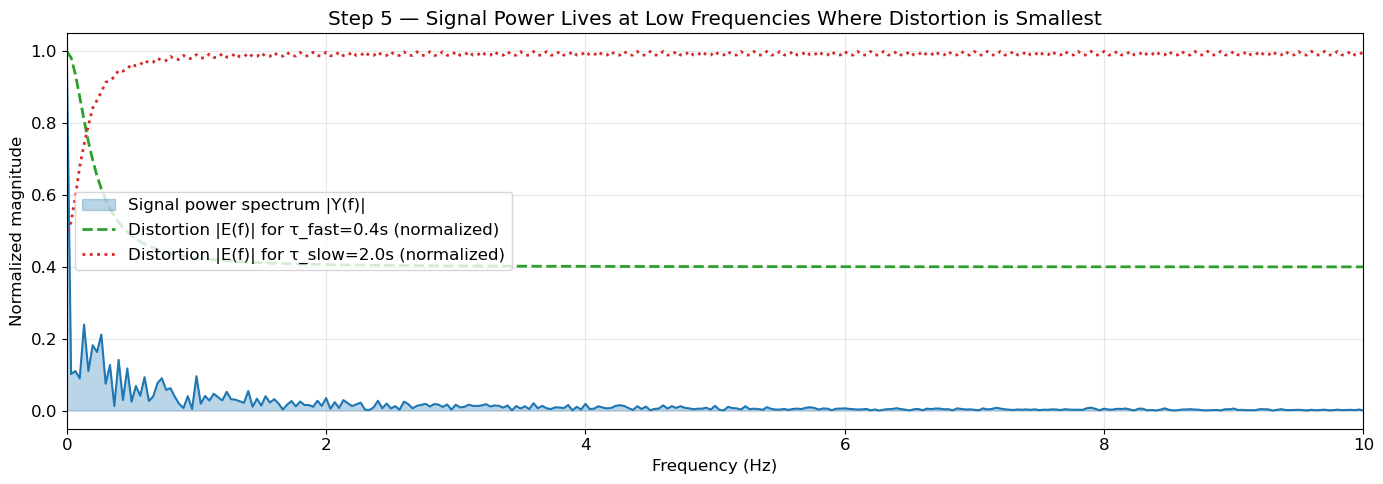


Key observation:
→ Signal power is concentrated at low frequencies (< 2 Hz)
→ Distortion E(f) is largest at high frequencies
→ The wrong tau distorts mostly the noise, not the neural signal


In [7]:
# --- Power spectrum of observed signal ---
Y_mag = np.abs(np.fft.rfft(y_noisy))

# Normalize for overlay
Y_norm    = Y_mag    / Y_mag.max()
E_fast_n  = E_fast   / E_fast.max()
E_slow_n  = E_slow   / E_slow.max()

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(freqs, Y_norm, alpha=0.3, color='C0', label='Signal power spectrum |Y(f)|')
ax.plot(freqs, Y_norm,   color='C0', linewidth=1.5)
ax.plot(freqs, E_fast_n, color='C2', linestyle='--',
        label=f'Distortion |E(f)| for τ_fast={tau_fast}s (normalized)')
ax.plot(freqs, E_slow_n, color='C3', linestyle=':',
        label=f'Distortion |E(f)| for τ_slow={tau_slow}s (normalized)')

ax.set_xlim([0, 10])
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Normalized magnitude')
ax.set_title('Step 5 — Signal Power Lives at Low Frequencies Where Distortion is Smallest')
ax.legend()

plt.tight_layout()
plt.show()

print("\nKey observation:")
print("→ Signal power is concentrated at low frequencies (< 2 Hz)")
print("→ Distortion E(f) is largest at high frequencies")
print("→ The wrong tau distorts mostly the noise, not the neural signal")

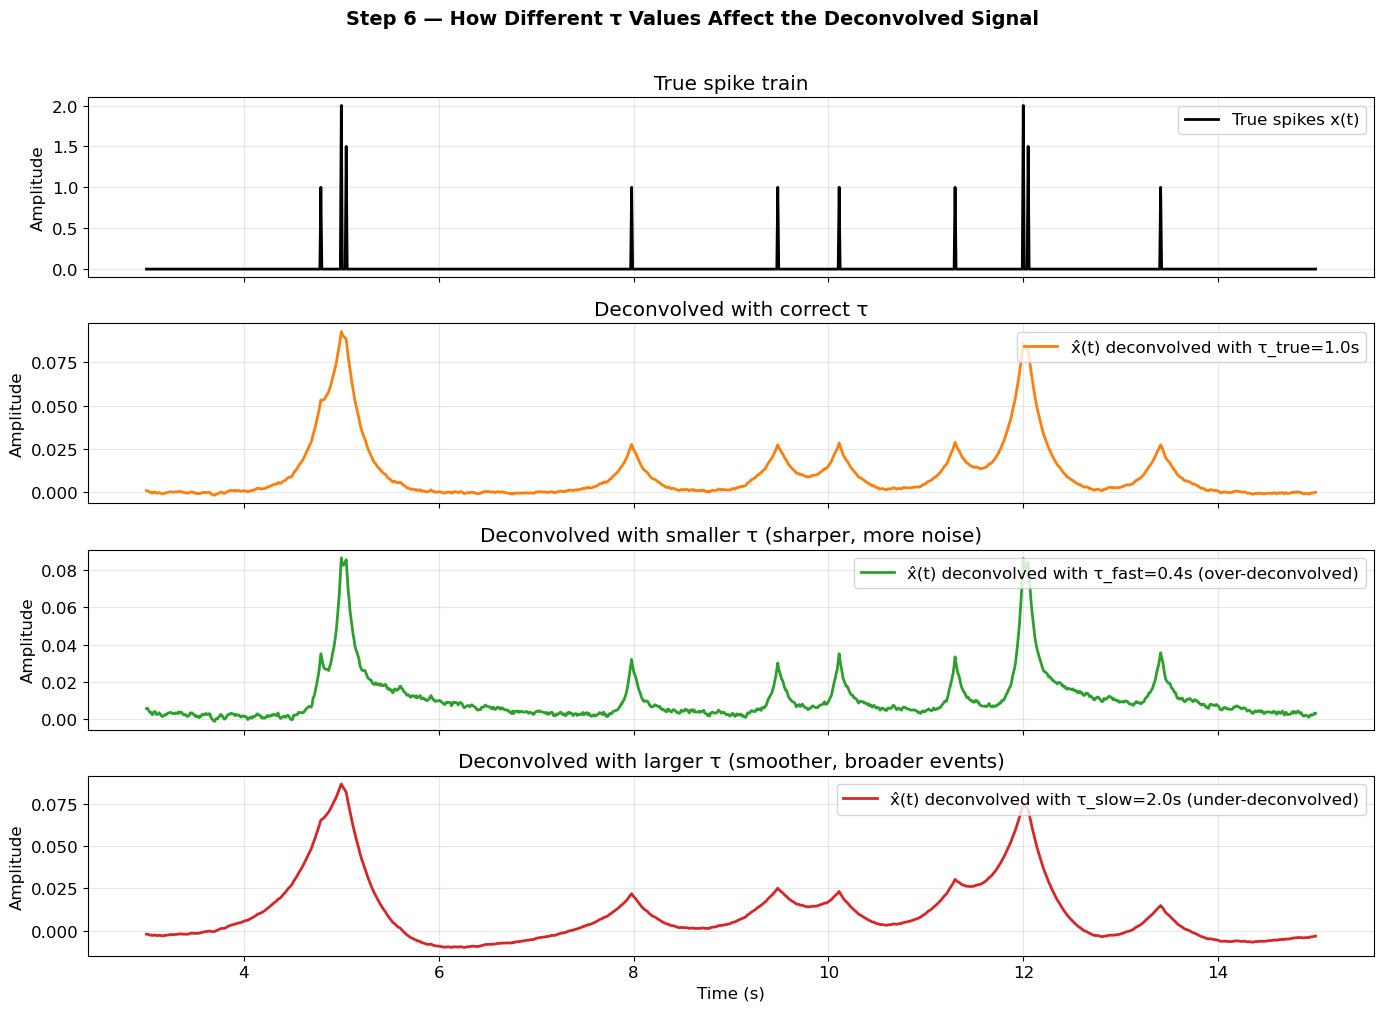

Key observation:
→ τ_fast=0.4s : sharper peaks, more noise amplified
→ τ_slow=2.0s : smoother peaks, events smeared in time
→ But event timing and relative structure are preserved in both cases


In [8]:
# --- Zoom into a region with clear activity ---
t_start, t_end = 3.0, 15.0
mask = (t >= t_start) & (t <= t_end)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(t[mask], spike_times[mask], color='k', label='True spikes x(t)')
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right')
axes[0].set_title('True spike train')

axes[1].plot(t[mask], x_hat_true[mask], color='C1',
             label=f'x̂(t) deconvolved with τ_true={tau_true}s')
axes[1].set_ylabel('Amplitude')
axes[1].legend(loc='upper right')
axes[1].set_title('Deconvolved with correct τ')

axes[2].plot(t[mask], x_hat_fast[mask], color='C2',
             label=f'x̂(t) deconvolved with τ_fast={tau_fast}s (over-deconvolved)')
axes[2].set_ylabel('Amplitude')
axes[2].legend(loc='upper right')
axes[2].set_title('Deconvolved with smaller τ (sharper, more noise)')

axes[3].plot(t[mask], x_hat_slow[mask], color='C3',
             label=f'x̂(t) deconvolved with τ_slow={tau_slow}s (under-deconvolved)')
axes[3].set_ylabel('Amplitude')
axes[3].set_xlabel('Time (s)')
axes[3].legend(loc='upper right')
axes[3].set_title('Deconvolved with larger τ (smoother, broader events)')

fig.suptitle('Step 6 — How Different τ Values Affect the Deconvolved Signal',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Key observation:")
print(f"→ τ_fast={tau_fast}s : sharper peaks, more noise amplified")
print(f"→ τ_slow={tau_slow}s : smoother peaks, events smeared in time")
print("→ But event timing and relative structure are preserved in both cases")